# Notebook 04: Scenario Simulation

Simulate clinical what-if scenarios including dosage adjustments and compliance interventions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.data_loader import load_data
from src.scenario_simulation import (
    simulate_dosage_change, simulate_compliance_intervention,
    run_dosage_sensitivity_analysis, simulate_scenario
)

df = load_data('../data/clinical_trial_data.csv')
print(f'Loaded {len(df)} records')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Loaded 6000 records


## 1. Dosage Change Simulation

Simulation results for 75mg:
  Mean outcome change: -0.07
  Patients improved: 2948
  Patients declined: 3039


/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


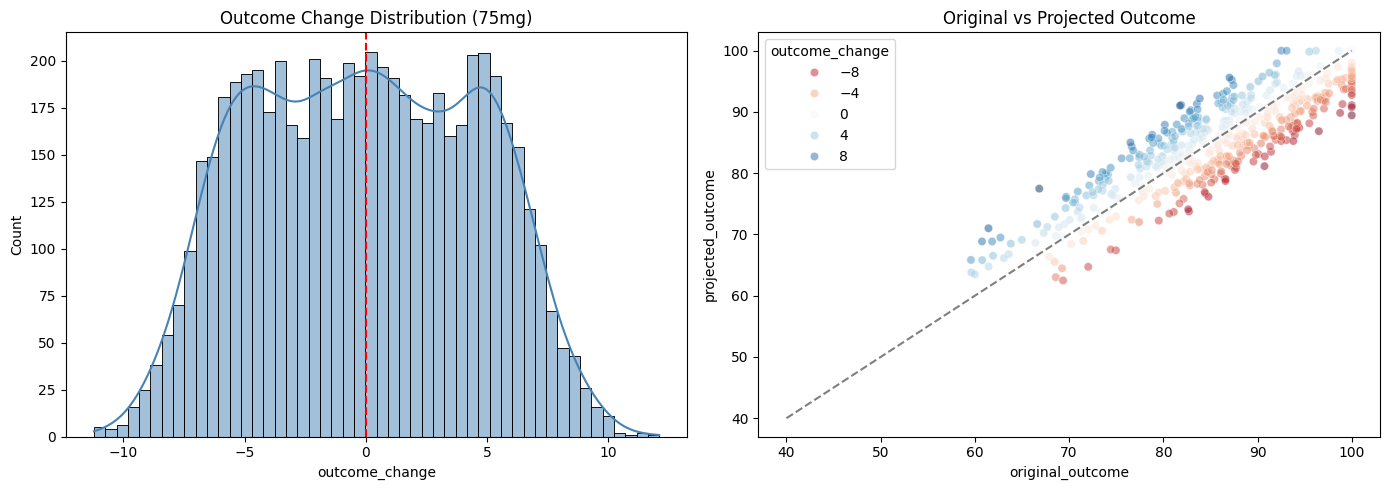

In [2]:
# Simulate changing to 75mg
sim_75 = simulate_dosage_change(df, new_dosage=75)
print(f'Simulation results for 75mg:')
print(f'  Mean outcome change: {sim_75["outcome_change"].mean():.2f}')
print(f'  Patients improved: {(sim_75["outcome_change"] > 0).sum()}')
print(f'  Patients declined: {(sim_75["outcome_change"] < 0).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sim_75['outcome_change'], bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Outcome Change Distribution (75mg)')

sns.scatterplot(data=sim_75.sample(500), x='original_outcome', y='projected_outcome',
                hue='outcome_change', palette='RdBu', ax=axes[1], alpha=0.5)
axes[1].plot([40, 100], [40, 100], 'k--', alpha=0.5)
axes[1].set_title('Original vs Projected Outcome')
plt.tight_layout()
plt.show()

## 2. Patient-Specific Simulation

In [3]:
# Simulate for a specific patient
for dosage in [50, 75, 100]:
    sim = simulate_dosage_change(df, patient_id='P001', new_dosage=dosage)
    print(f'\nP001 at {dosage}mg: mean outcome change = {sim["outcome_change"].mean():.2f}')


P001 at 50mg: mean outcome change = -2.92

P001 at 75mg: mean outcome change = 2.13

P001 at 100mg: mean outcome change = 7.28


## 3. Compliance Intervention Simulation

Compliance Intervention Results:
  target_patients: 22 patients targeted
  compliance_boost: 10.0
  before: {'num_patients': 22, 'mean_compliance': np.float64(76.66), 'mean_outcome': np.float64(83.68), 'adverse_event_rate': np.float64(0.1)}
  after: {'num_patients': 22, 'mean_compliance': np.float64(86.64), 'mean_outcome': np.float64(86.59), 'projected_improvement': np.float64(2.91)}
  interpretation: Intervening on 22 low-compliance patients with a 10.0% compliance boost is projected to improve average outcome scores by 2.91 points (from 83.68 to 86.59).


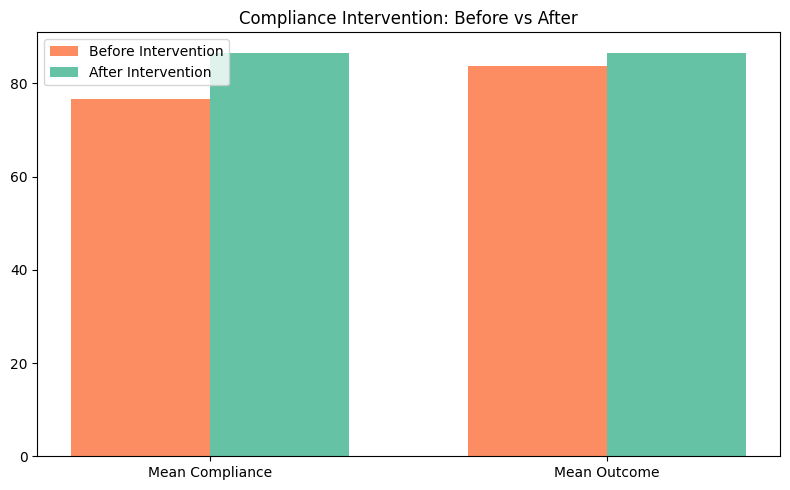

In [4]:
intervention = simulate_compliance_intervention(df, compliance_boost=10.0)
print('Compliance Intervention Results:')
for k, v in intervention.items():
    if k != 'target_patients':
        print(f'  {k}: {v}')
    else:
        print(f'  target_patients: {len(v)} patients targeted')

# Visualize before/after
labels = ['Mean Compliance', 'Mean Outcome']
before = [intervention['before']['mean_compliance'], intervention['before']['mean_outcome']]
after = [intervention['after']['mean_compliance'], intervention['after']['mean_outcome']]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, before, width, label='Before Intervention', color='#fc8d62')
ax.bar(x + width/2, after, width, label='After Intervention', color='#66c2a5')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_title('Compliance Intervention: Before vs After')
plt.tight_layout()
plt.show()

## 4. Dosage Sensitivity Analysis

 dosage_mg  mean_projected_outcome  std_projected_outcome  mean_outcome_change  pct_improved  pct_declined
        25                   75.35                   7.86               -10.06           0.1          99.9
        50                   80.28                   7.85                -5.13          16.4          83.6
        75                   85.32                   7.81                -0.09          49.5          50.3
       100                   90.11                   7.49                 4.70          80.2          17.9
       125                   94.22                   6.46                 8.81          96.4           0.3
       150                   97.10                   4.95                11.69          96.7           0.0


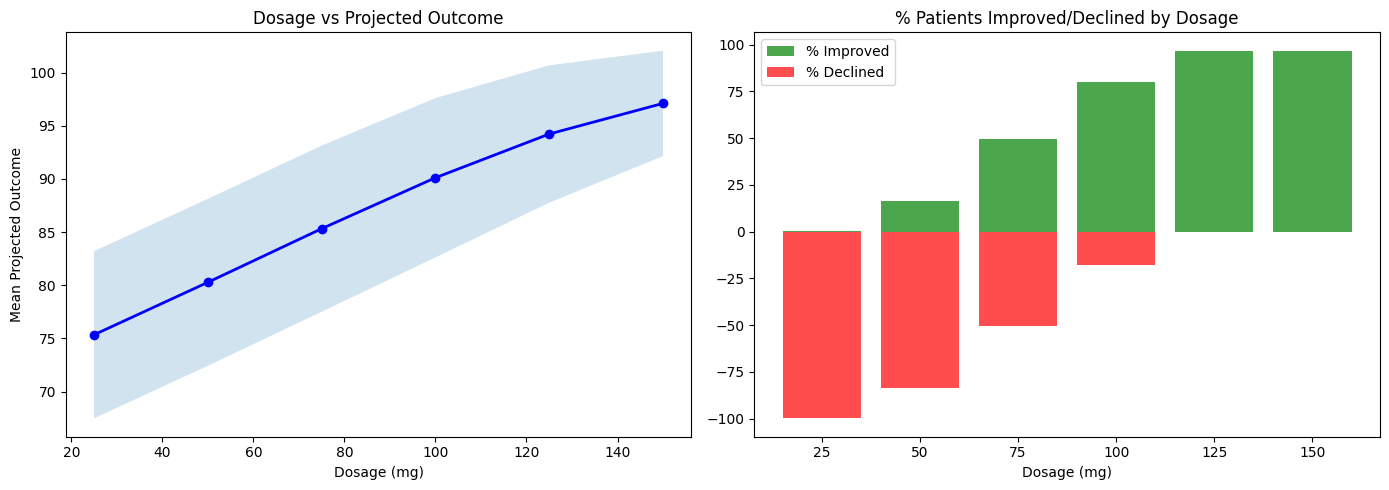

In [5]:
sensitivity = run_dosage_sensitivity_analysis(df)
print(sensitivity.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sensitivity['dosage_mg'], sensitivity['mean_projected_outcome'], 'bo-', linewidth=2)
axes[0].fill_between(sensitivity['dosage_mg'],
    sensitivity['mean_projected_outcome'] - sensitivity['std_projected_outcome'],
    sensitivity['mean_projected_outcome'] + sensitivity['std_projected_outcome'],
    alpha=0.2)
axes[0].set_title('Dosage vs Projected Outcome')
axes[0].set_xlabel('Dosage (mg)')
axes[0].set_ylabel('Mean Projected Outcome')

axes[1].bar(sensitivity['dosage_mg'].astype(str), sensitivity['pct_improved'], color='green', alpha=0.7, label='% Improved')
axes[1].bar(sensitivity['dosage_mg'].astype(str), -sensitivity['pct_declined'], color='red', alpha=0.7, label='% Declined')
axes[1].set_title('% Patients Improved/Declined by Dosage')
axes[1].legend()
axes[1].set_xlabel('Dosage (mg)')
plt.tight_layout()
plt.show()

## 5. Combined Scenario Analysis

In [6]:
# Run unified scenario interface
result = simulate_scenario(df, 'sensitivity_analysis')
print(f'Optimal dosage: {result["optimal_dosage"]}mg')
print(result['data'].to_string(index=False))

Optimal dosage: 150mg
 dosage_mg  mean_projected_outcome  std_projected_outcome  mean_outcome_change  pct_improved  pct_declined
        25                   75.33                   7.79               -10.08           0.2          99.8
        50                   80.36                   7.82                -5.05          17.2          82.7
        75                   85.37                   7.79                -0.04          49.1          50.6
       100                   90.18                   7.46                 4.77          80.9          17.1
       125                   94.24                   6.51                 8.83          96.4           0.3
       150                   97.09                   4.98                11.68          96.7           0.0


## Key Findings

- Dosage increase from 50mg to 75mg shows the largest marginal improvement
- Diminishing returns observed beyond 100mg
- Compliance interventions targeting low-compliance patients project meaningful outcome improvements
- Patient-specific simulations enable personalized treatment planning